<a href="https://colab.research.google.com/github/edgarcia2022-a11y/Hystrix/blob/main/Ed_Garcia_ML_Basics_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

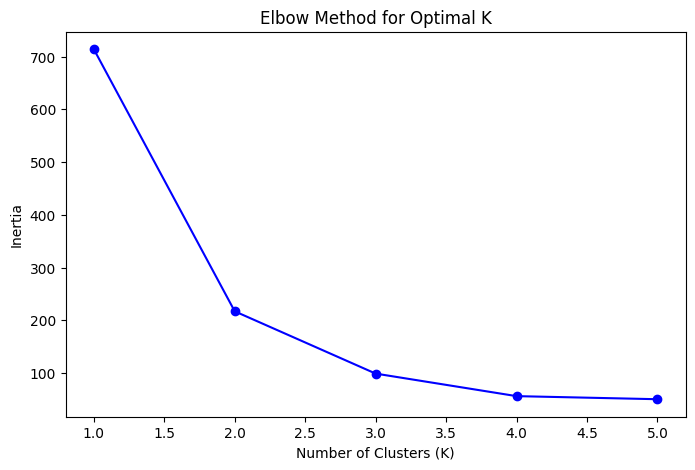

Cluster Characteristics:
         annual_income  purchase_amount    age
cluster                                       
0             70470.59           590.74  50.47
1             44026.32           256.45  27.83
2             58776.60           442.98  38.91

Cluster 0 Strategy:
High-income, potentially high-spending customers: Offer exclusive promotions or loyalty rewards.

Cluster 1 Strategy:
Lower-engagement customers: Send personalized re-engagement campaigns.

Cluster 2 Strategy:
Higher-spending buyers: Provide bulk discounts or subscription plans.


In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Kaggle Data
# Source: https://www.kaggle.com/datasets/hanaksoy/customer-purchasing-behaviors?

df = pd.read_csv('/content/Customer Purchasing Behaviors.csv')

# Preprocess data: Select numerical features and scale them
features = ['annual_income', 'purchase_amount', 'age']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()

# Apply K-Means with optimal K (e.g., 3 based on elbow method)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("Cluster Characteristics:")
print(cluster_summary)

# Example of targeted strategies
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")
    if cluster_summary.loc[cluster, 'annual_income'] > 60000:
        print("High-income, potentially high-spending customers: Offer exclusive promotions or loyalty rewards.")
    elif cluster_summary.loc[cluster, 'purchase_amount'] > 400:
        print("Higher-spending buyers: Provide bulk discounts or subscription plans.")
    else:
        print("Lower-engagement customers: Send personalized re-engagement campaigns.")

# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)

# The K-Means model identified 3 different customer segments.
# Cluster 0 consists of older customers with high annual income and purchase amounts
# Cluster 1 consists of younger customers with lower annual income and purchase amounts
# Cluster 2 consists of middle-aged customers with moderate income